In [18]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
import pandas as pd
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [19]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


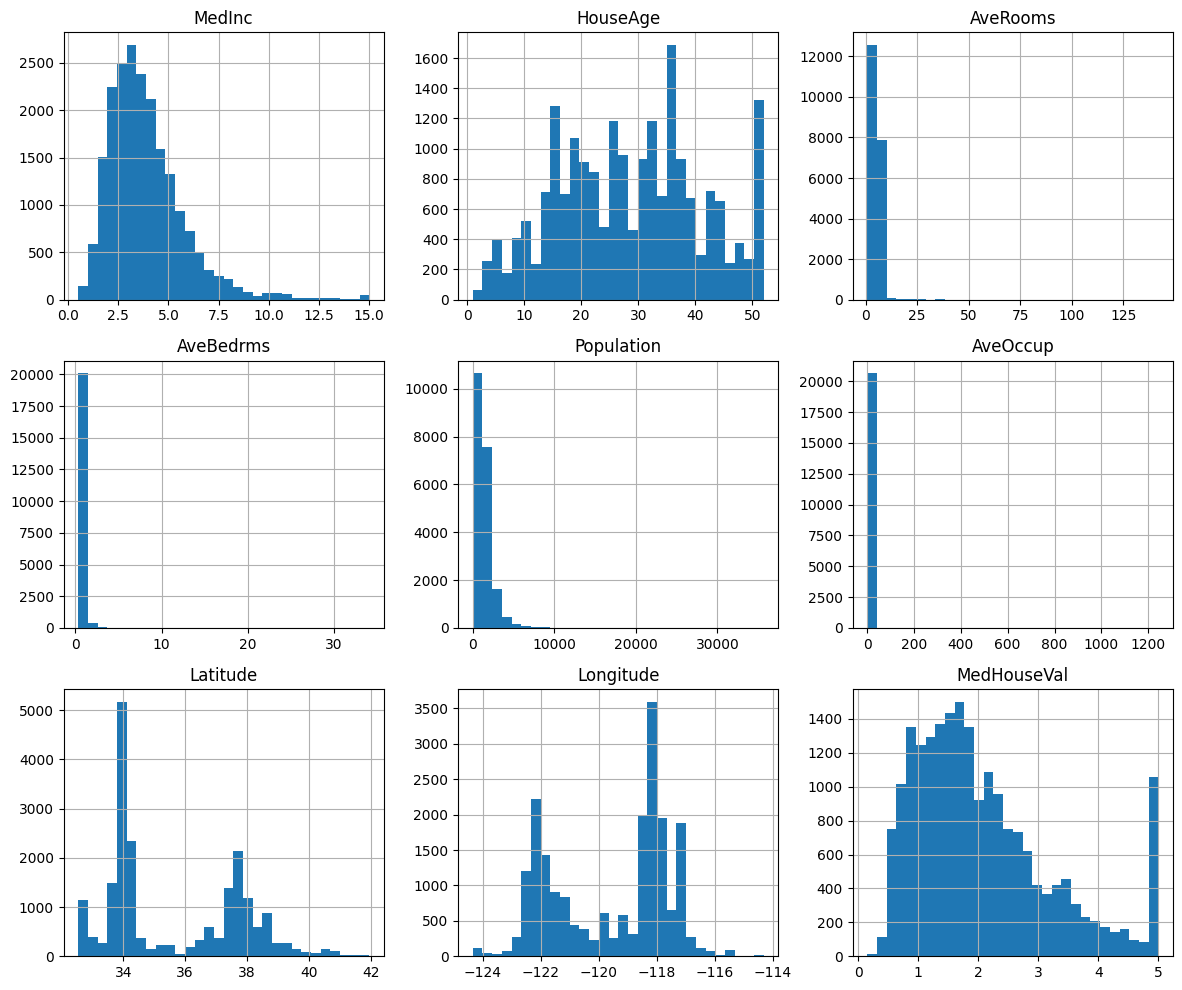

In [20]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

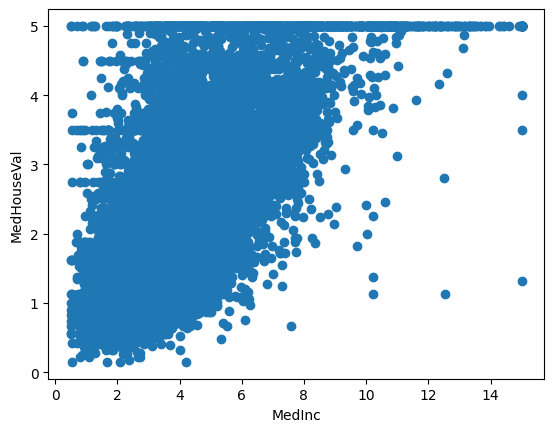

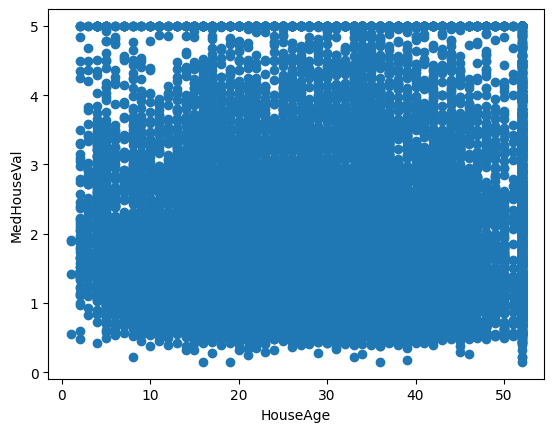

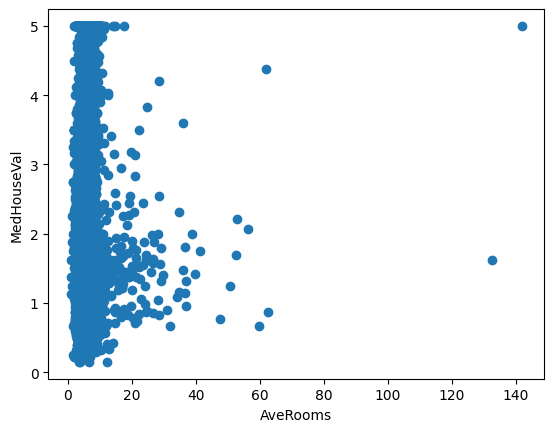

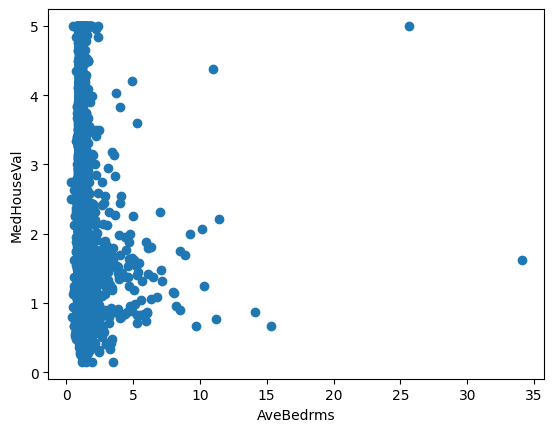

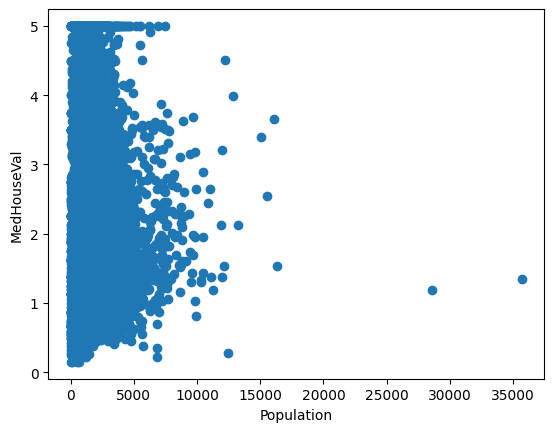

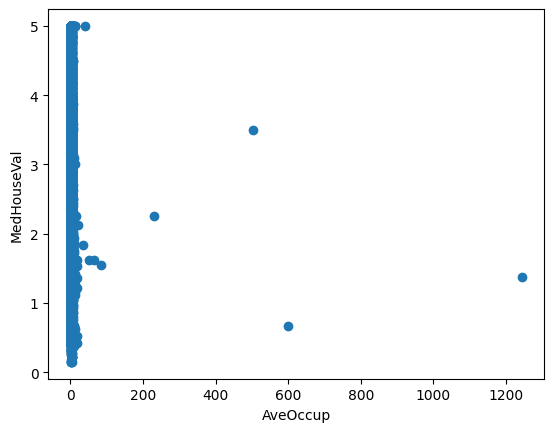

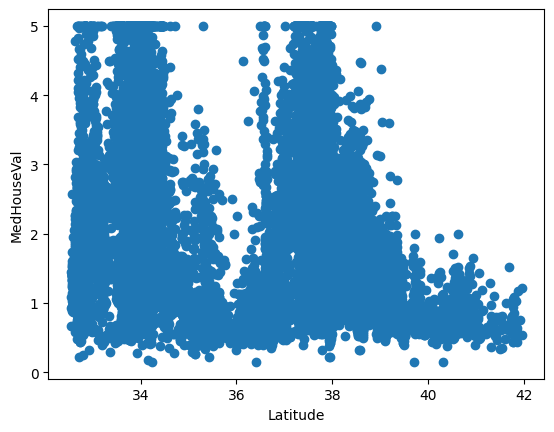

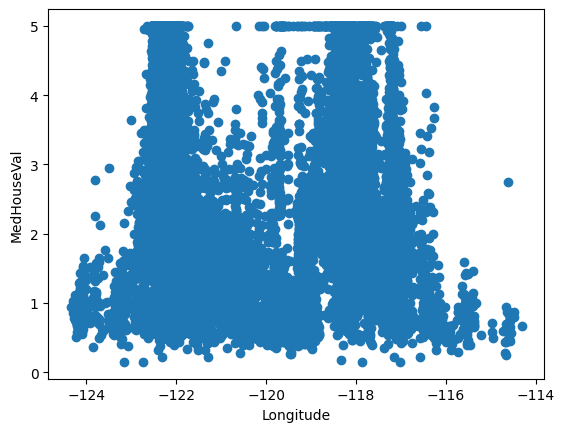

In [21]:
for col in df.columns[:-1]:
    plt.figure()
    plt.scatter(df[col], df['MedHouseVal'])
    plt.xlabel(col)
    plt.ylabel('MedHouseVal')
    plt.show()

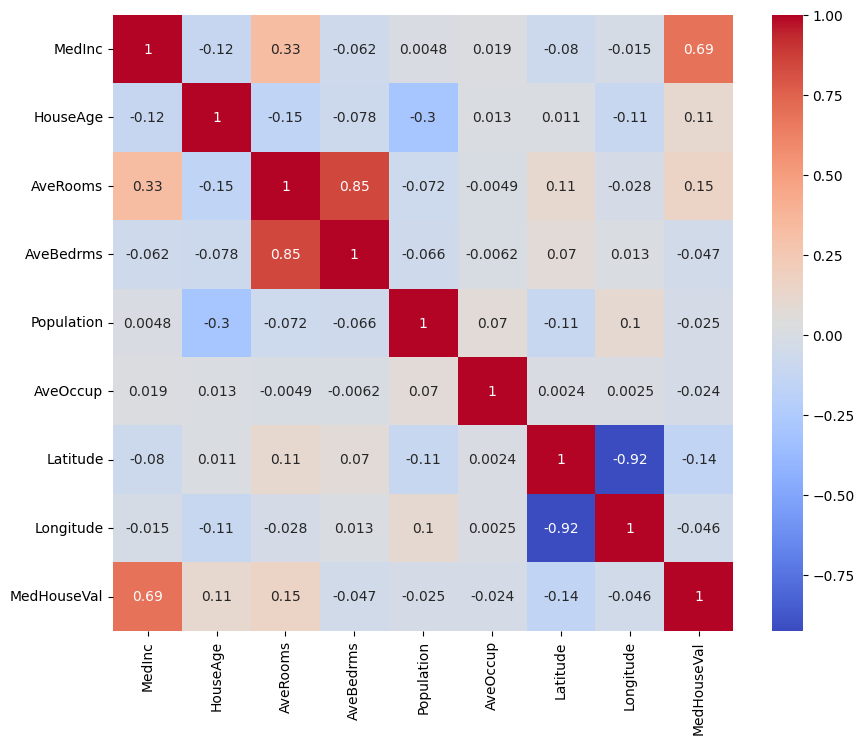

In [22]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [23]:
import statsmodels.api as sm

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     3970.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:06:20   Log-Likelihood:                -22624.
No. Observations:               20640   AIC:                         4.527e+04
Df Residuals:                   20631   BIC:                         4.534e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.9419      0.659    -56.067      0.0

In [24]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     3970.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:06:20   Log-Likelihood:                -22624.
No. Observations:               20640   AIC:                         4.527e+04
Df Residuals:                   20631   BIC:                         4.534e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.9419      0.659    -56.067      0.0

In [25]:
print("\nP-values in scientific notation:")
pvals = pd.DataFrame({
    'Variable': model.params.index,
    'p-value': model.pvalues
})

print(pvals.to_string(index=False, float_format="{:.10e}".format))


P-values in scientific notation:
  Variable           p-value
     const  0.0000000000e+00
    MedInc  0.0000000000e+00
  HouseAge  3.5054851558e-98
  AveRooms  1.0263111221e-73
 AveBedrms 6.7257255634e-115
Population  4.0244719609e-01
  AveOccup  8.3036942343e-15
  Latitude  0.0000000000e+00
 Longitude  0.0000000000e+00


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

      Feature           VIF
0       const  17082.623698
1      MedInc      2.501295
2    HouseAge      1.241254
3    AveRooms      8.342786
4   AveBedrms      6.994995
5  Population      1.138125
6    AveOccup      1.008324
7    Latitude      9.297624
8   Longitude      8.962263


In [27]:
X_refined = df.drop(['MedHouseVal', 'AveBedrms'], axis=1)
X_refined = sm.add_constant(X_refined)

model_refined = sm.OLS(y, X_refined).fit()
print(model_refined.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     4352.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:06:21   Log-Likelihood:                -22883.
No. Observations:               20640   AIC:                         4.578e+04
Df Residuals:                   20632   BIC:                         4.585e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -39.0492      0.661    -59.103      0.0

In [28]:
import numpy as np
y_log = np.log(df['MedHouseVal'])

model_log = sm.OLS(y_log, X_refined).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     4589.
Date:                Thu, 05 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:06:21   Log-Likelihood:                -7964.0
No. Observations:               20640   AIC:                         1.594e+04
Df Residuals:                   20632   BIC:                         1.601e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -25.0116      0.321    -77.995      0.0

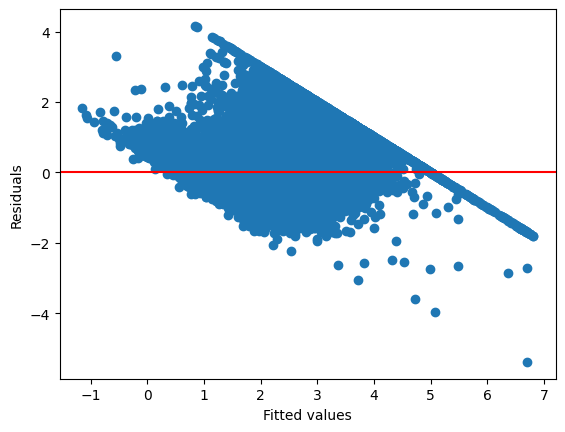

In [30]:
residuals = model_refined.resid

plt.scatter(model_refined.fittedvalues, residuals)
plt.axhline(0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)                  
mse = mean_squared_error(y_test, y_pred)       
rmse = np.sqrt(mse)                            

print("Test R²:", r2)
print("Test RMSE:", rmse)

Test R²: 0.5757877060324511
Test RMSE: 0.7455813830127761
